In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

parquet_file = Path("./results.parquet")
df = pd.read_parquet(parquet_file)

HUE_ORDER = ["prolog", "EdgeWise", "EdgeWise (cr)"]
COL_ORDER = ["arFarming", "distSecurity", "speakToMe"]
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Set FONT SIZE of x-axis and y-axis, legend, etc.
FONT_SIZE = 14
rc = {
    "axes.labelsize": FONT_SIZE,
    "font.size": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "legend.title_fontsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
}

sns.set_theme(style="whitegrid", palette="colorblind", context="notebook", rc=rc)
pd.set_option("display.max_rows", None)

df = df[df["version"].isin(HUE_ORDER)]

In [6]:
grouping_columns = ["n_event", "topology", "version", "nodes", "application_id", "seed"]
# Identify the groups where "is_placed" is False
events_to_remove = df[(df["callback_id"] == "is_placed") & (df["value"] == "False")][
    grouping_columns
].drop_duplicates()

# Perform an anti-join to remove groups
old_shape = df.shape
df = df.merge(events_to_remove, on=grouping_columns, how="left", indicator=True)
df = df[df["_merge"] == "left_only"].drop(columns=["_merge"])
print(f"Removed {old_shape[0] - df.shape[0]} events")

Removed 29755 events


In [7]:
df_exec_time = df[(df["callback_id"] == "execution_time") & (~df["value"].isin(["-1"]))]
df_exec_time.loc[:, "value"] = df_exec_time["value"].astype(float)

df_cost = df[(df["callback_id"] == "cost") & (~df["value"].isin(["inf", "-1"]))]
df_cost.loc[:, "value"] = df_cost["value"].astype(float)

df_moved = df[(df["callback_id"] == "moved_services") & (~df["value"].isin(["inf", "-1"]))]
df_moved.loc[:, "value"] = df_moved["value"].astype(float)

## EXECUTION TIME

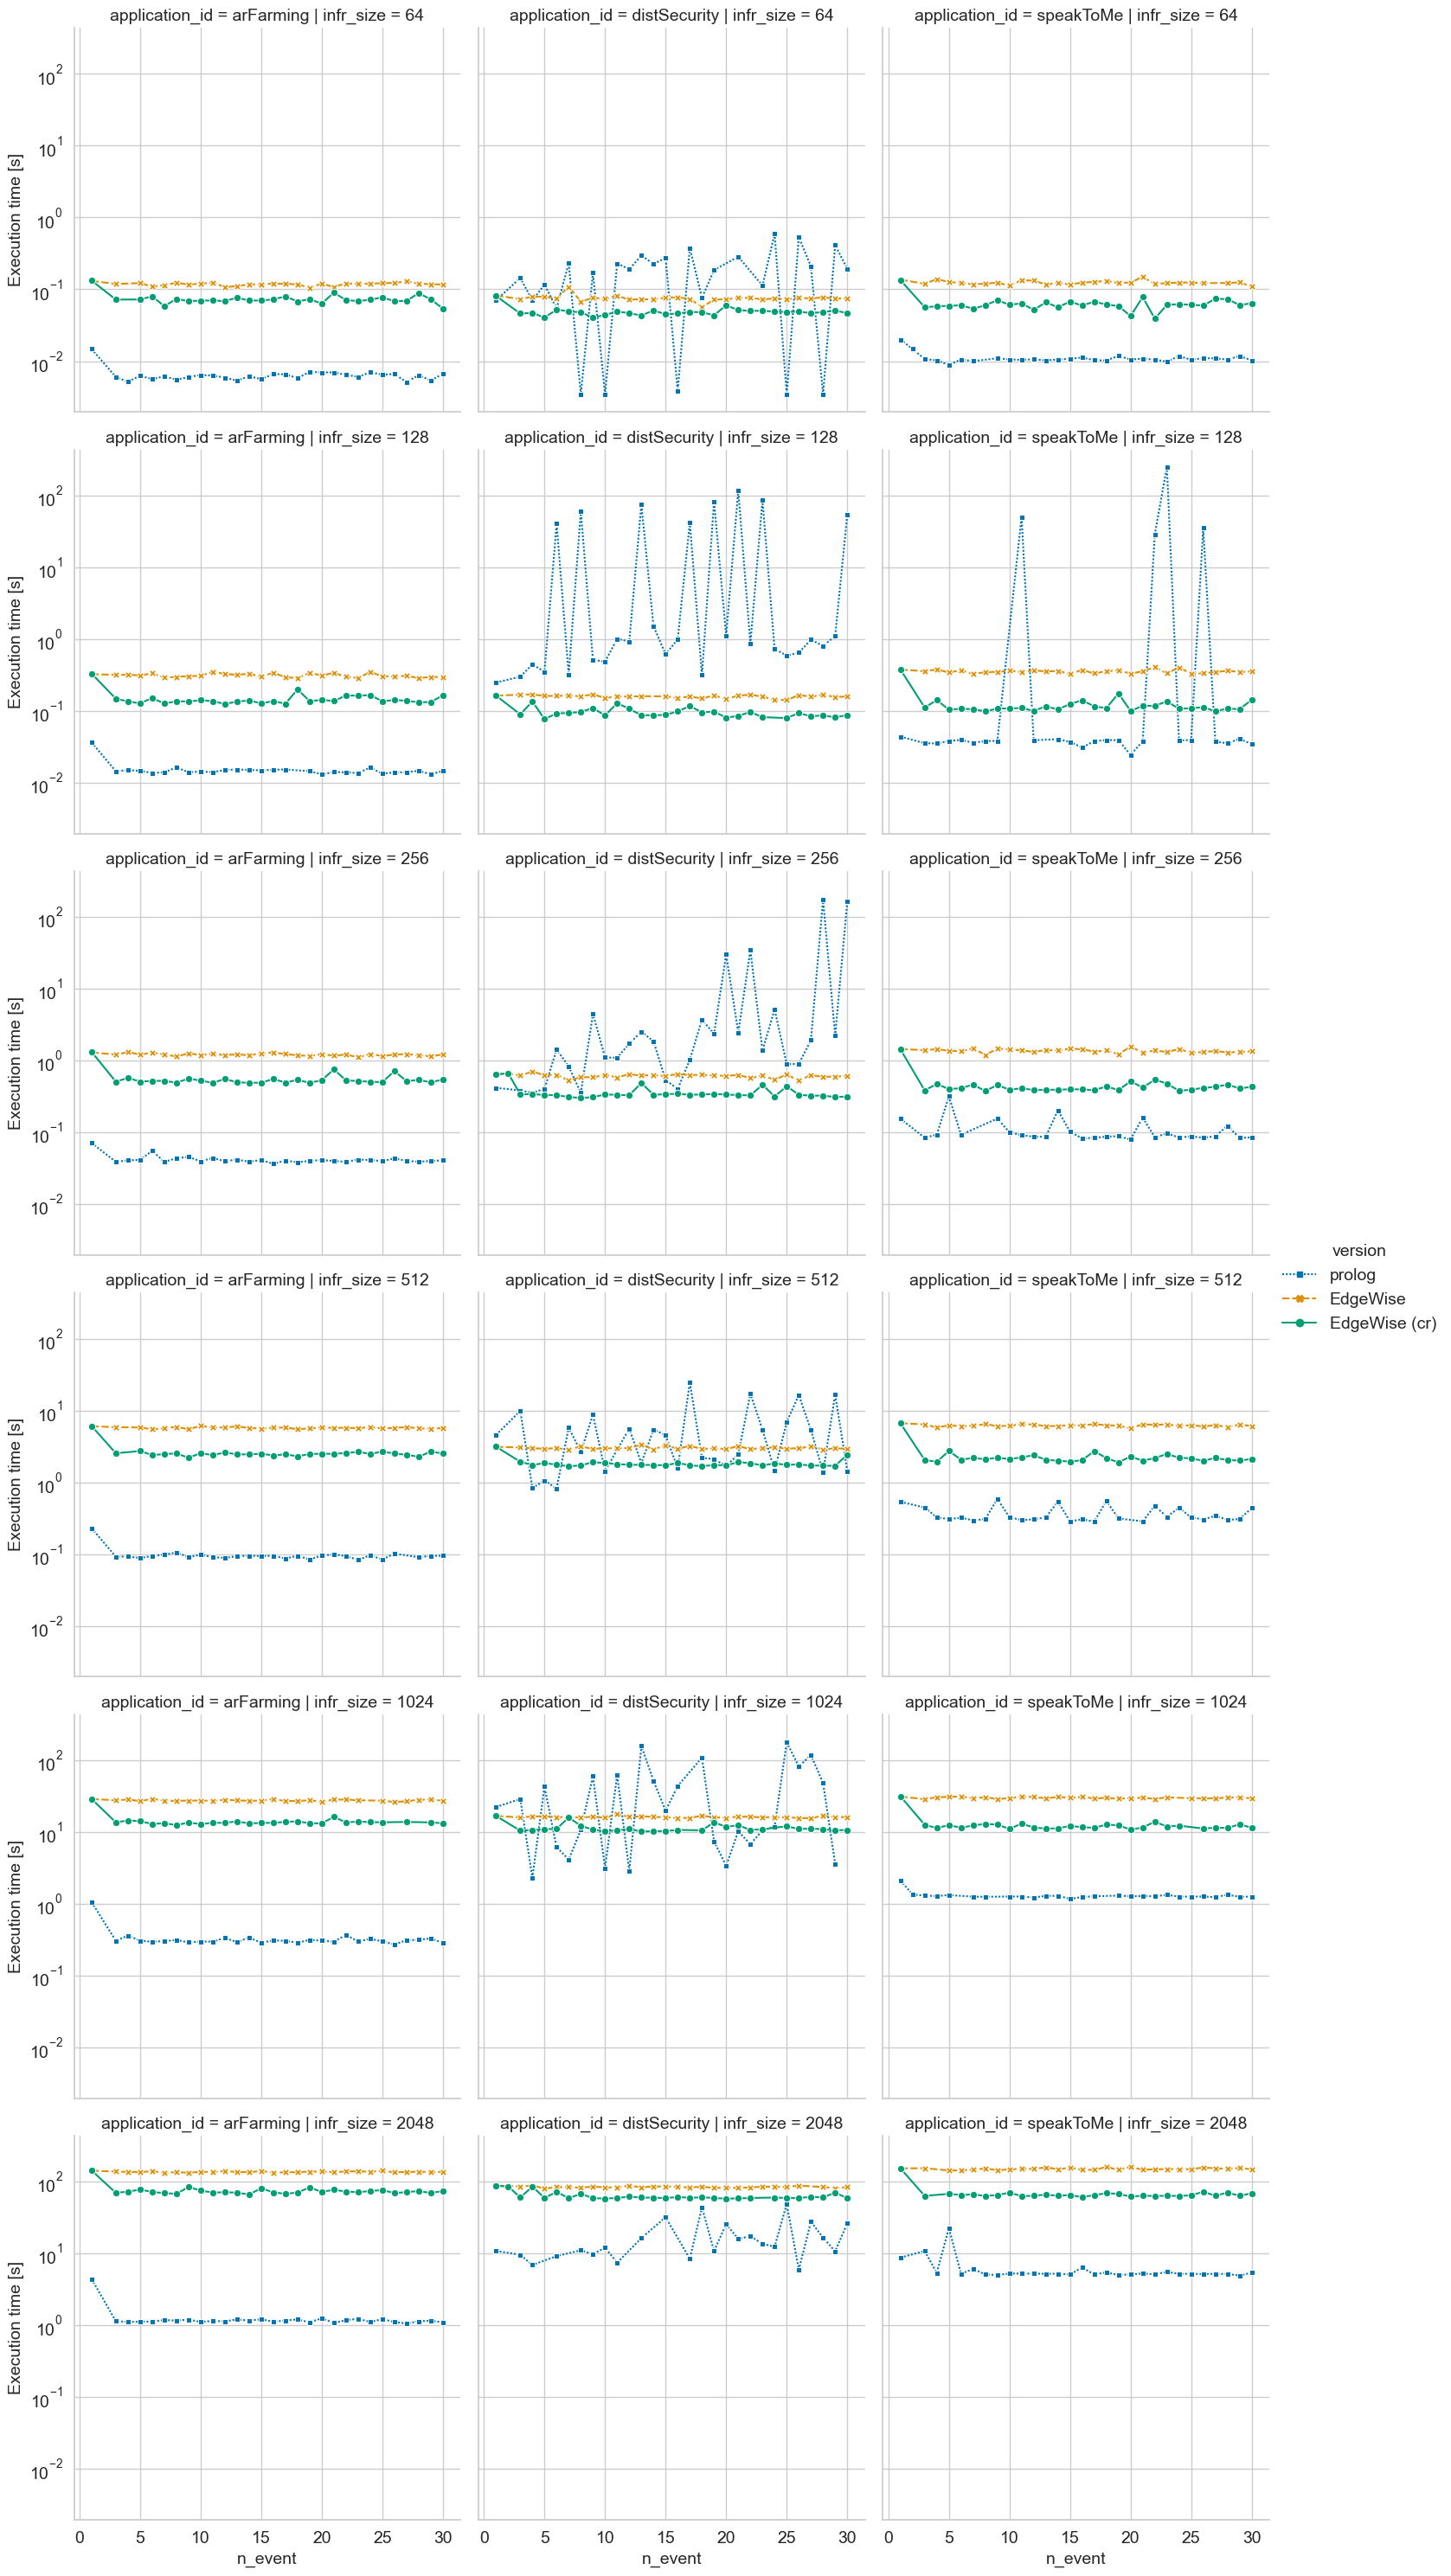

In [ ]:
f = sns.relplot(
    data=df_exec_time,
    x="n_event",
    y="value",
    hue="version",
    style="version",
    markers=True,
    kind="line",
    row="nodes",
    col="application_id",
    palette="colorblind",
    errorbar=None,
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set(yscale="log")
# f.set(ylim=(0, 160))
f.set_ylabels("Execution time [s]")
f.savefig(PLOTS_DIR / "execution_time.pdf", format="pdf", dpi=600)

### EXEC TIME DIFFERENCE (MILP / MILP (CR))

/var/folders/1r/_v8l8s4s5szdklfbt8tg7dwm0000gn/T/ipykernel_65263/425874073.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  f = sns.relplot(


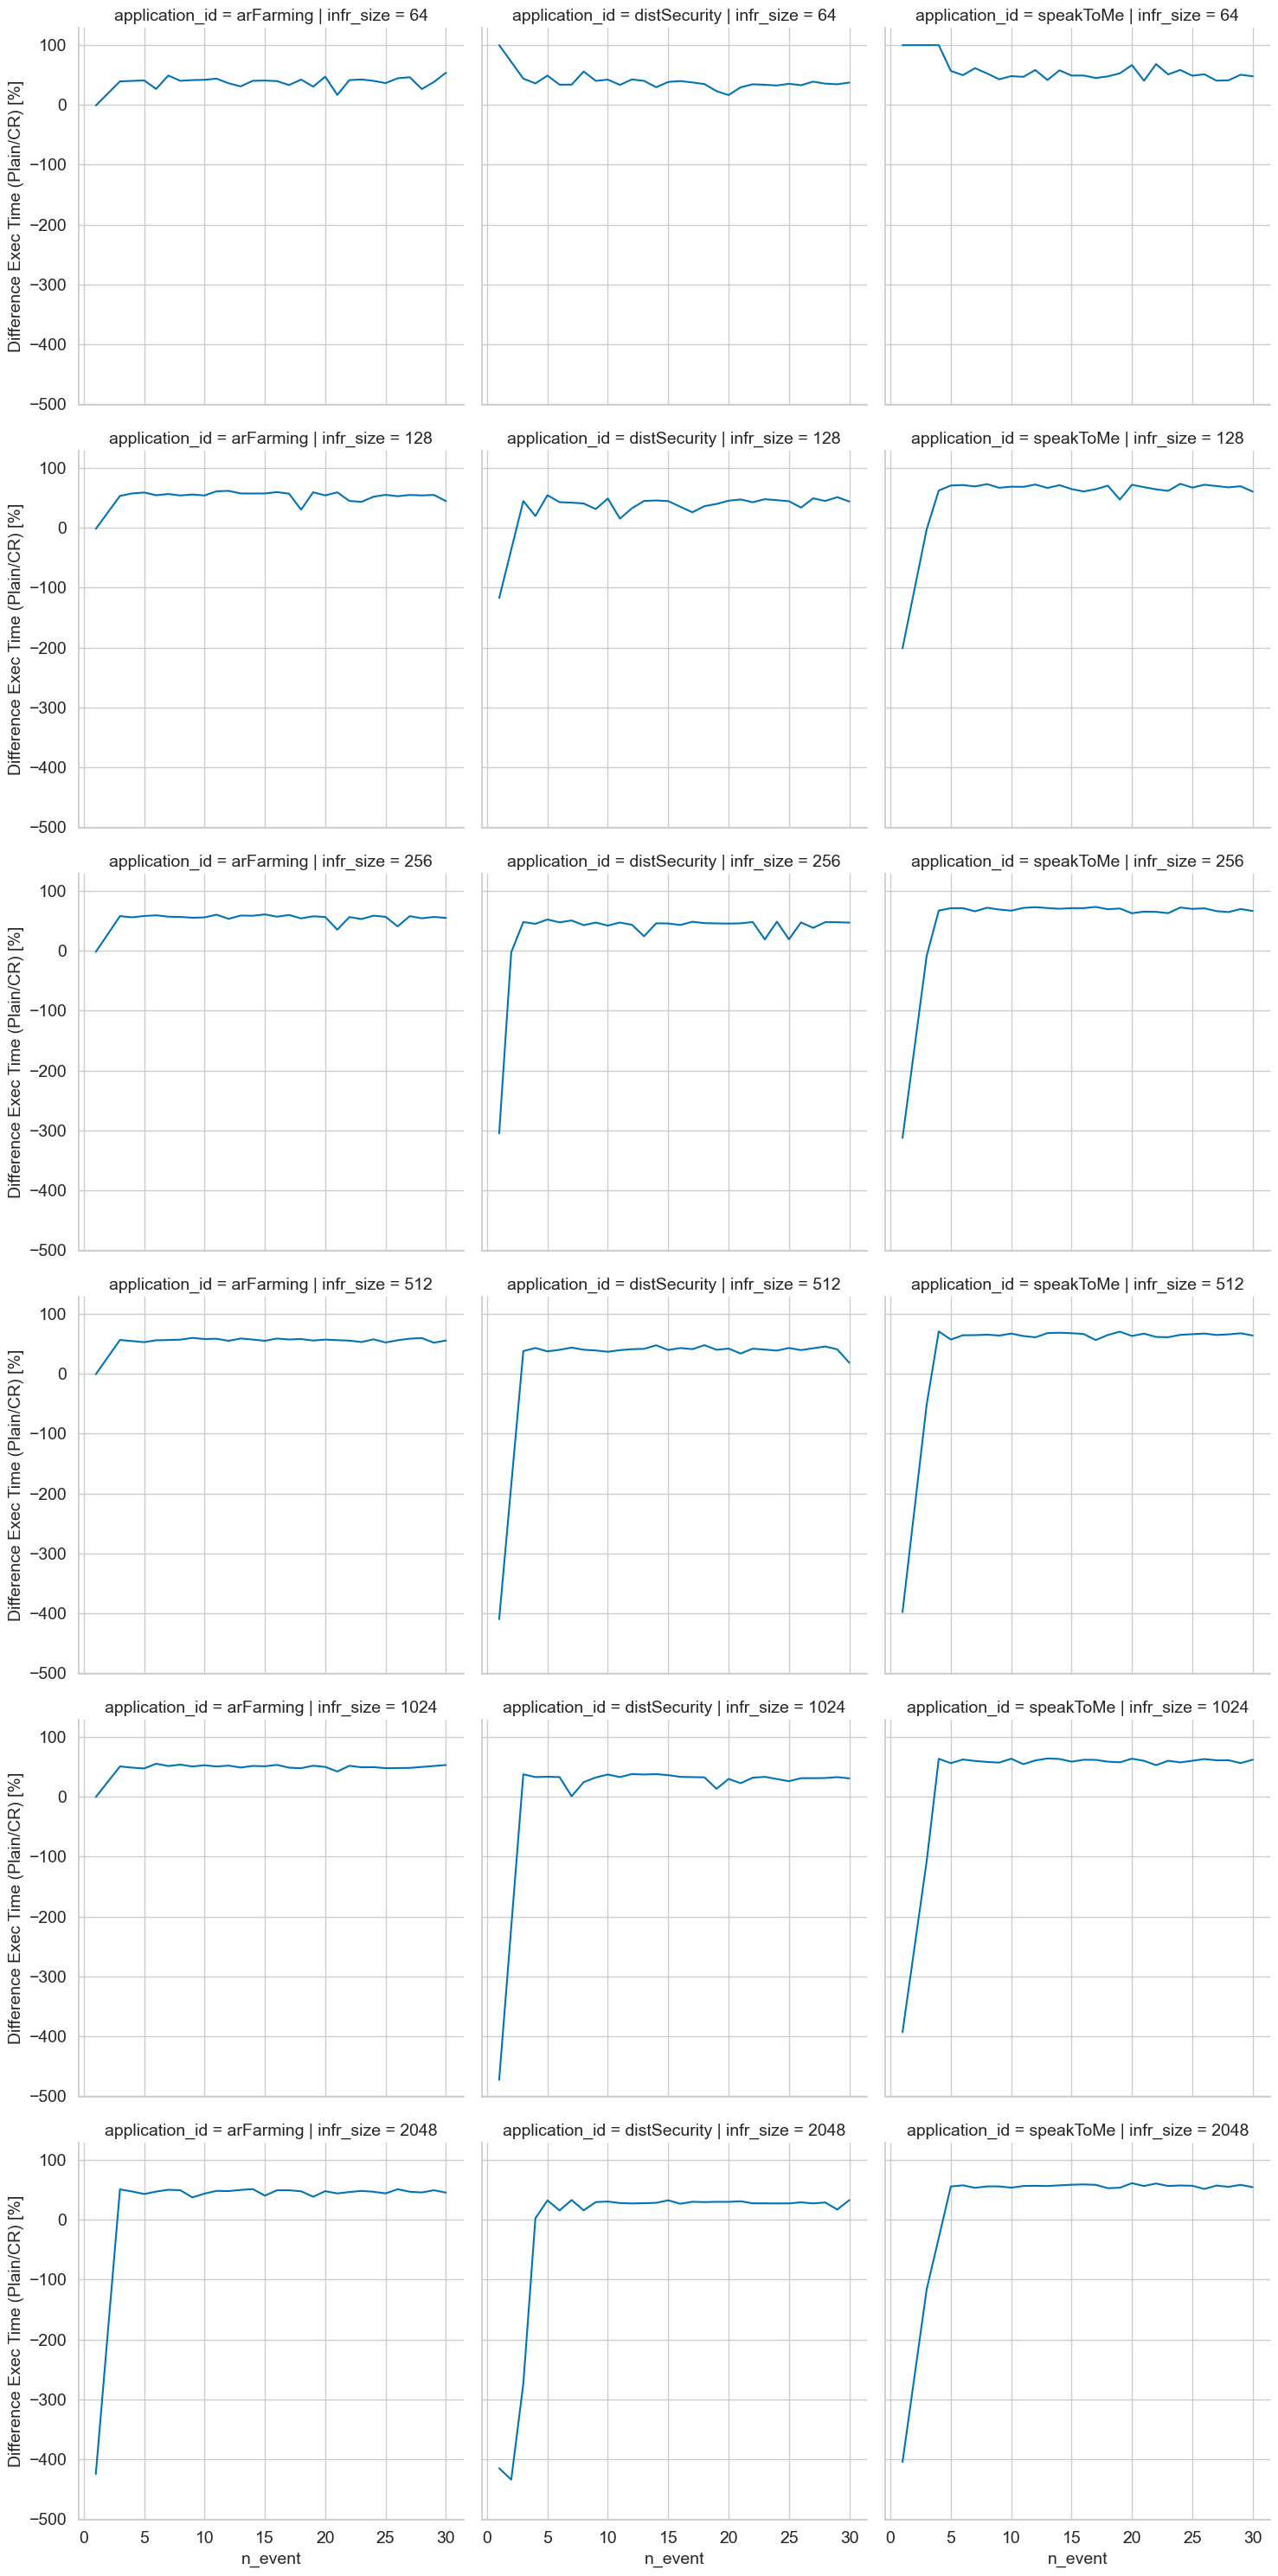

In [126]:
df_milp_et = df_exec_time[df_exec_time["version"] == "EdgeWise"]
df_milp_cr_et = df_exec_time[df_exec_time["version"] == "EdgeWise (cr)"]

df_milp_et = (
    df_milp_et.groupby(["application_id", "nodes", "n_event", "version"])["value"]
    .mean()
    .reset_index()
)
df_milp_cr_et = (
    df_milp_cr_et.groupby(["application_id", "nodes", "n_event", "version"])["value"]
    .mean()
    .reset_index()
)
df_milp_cr_et["diff"] = (
    (df_milp_et["value"] - df_milp_cr_et["value"]) / df_milp_et["value"]
) * 100

f = sns.relplot(
    data=df_milp_cr_et,
    x="n_event",
    y="diff",
    kind="line",
    markers=True,
    row="nodes",
    col="application_id",
    palette="colorblind",
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
    # errorbar=None,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Difference Exec Time (Plain/CR) [%]")

## COST

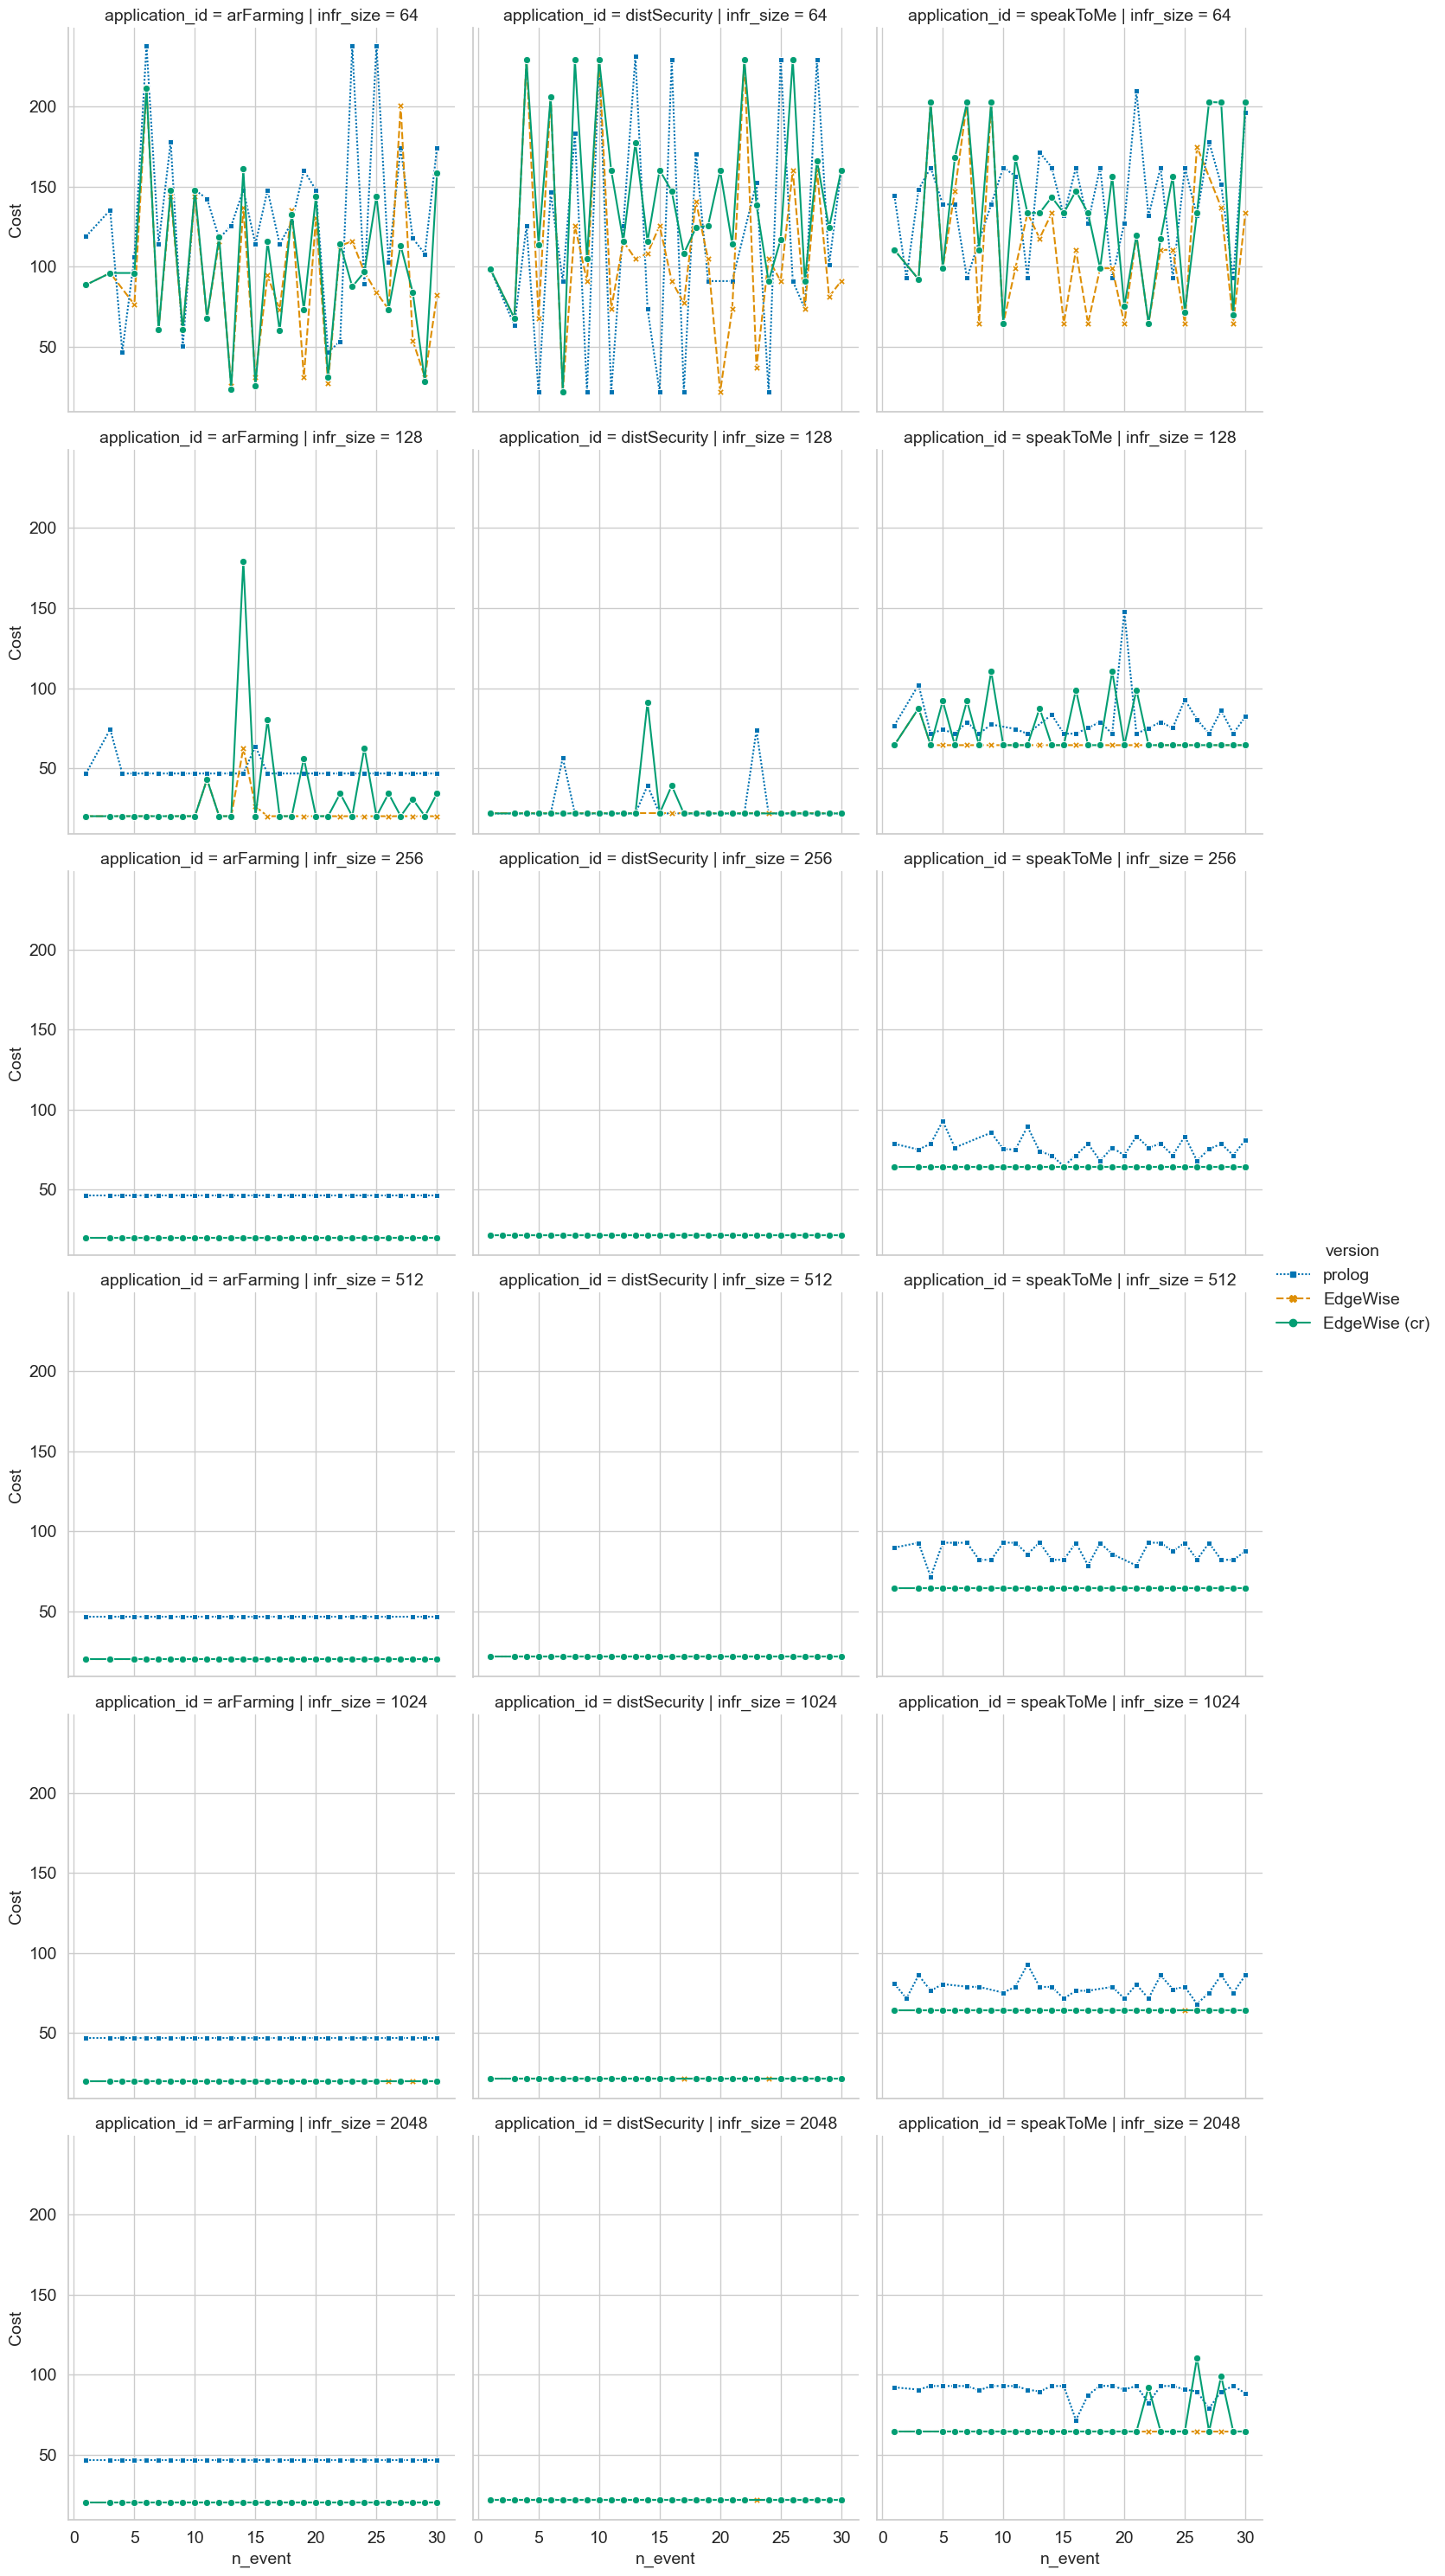

In [ ]:
f = sns.relplot(
    data=df_cost,
    x="n_event",
    y="value",
    hue="version",
    style="version",
    kind="line",
    row="nodes",
    col="application_id",
    palette="colorblind",
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
    markers=True,
    errorbar=None,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Cost")

## MOVED SERVICES

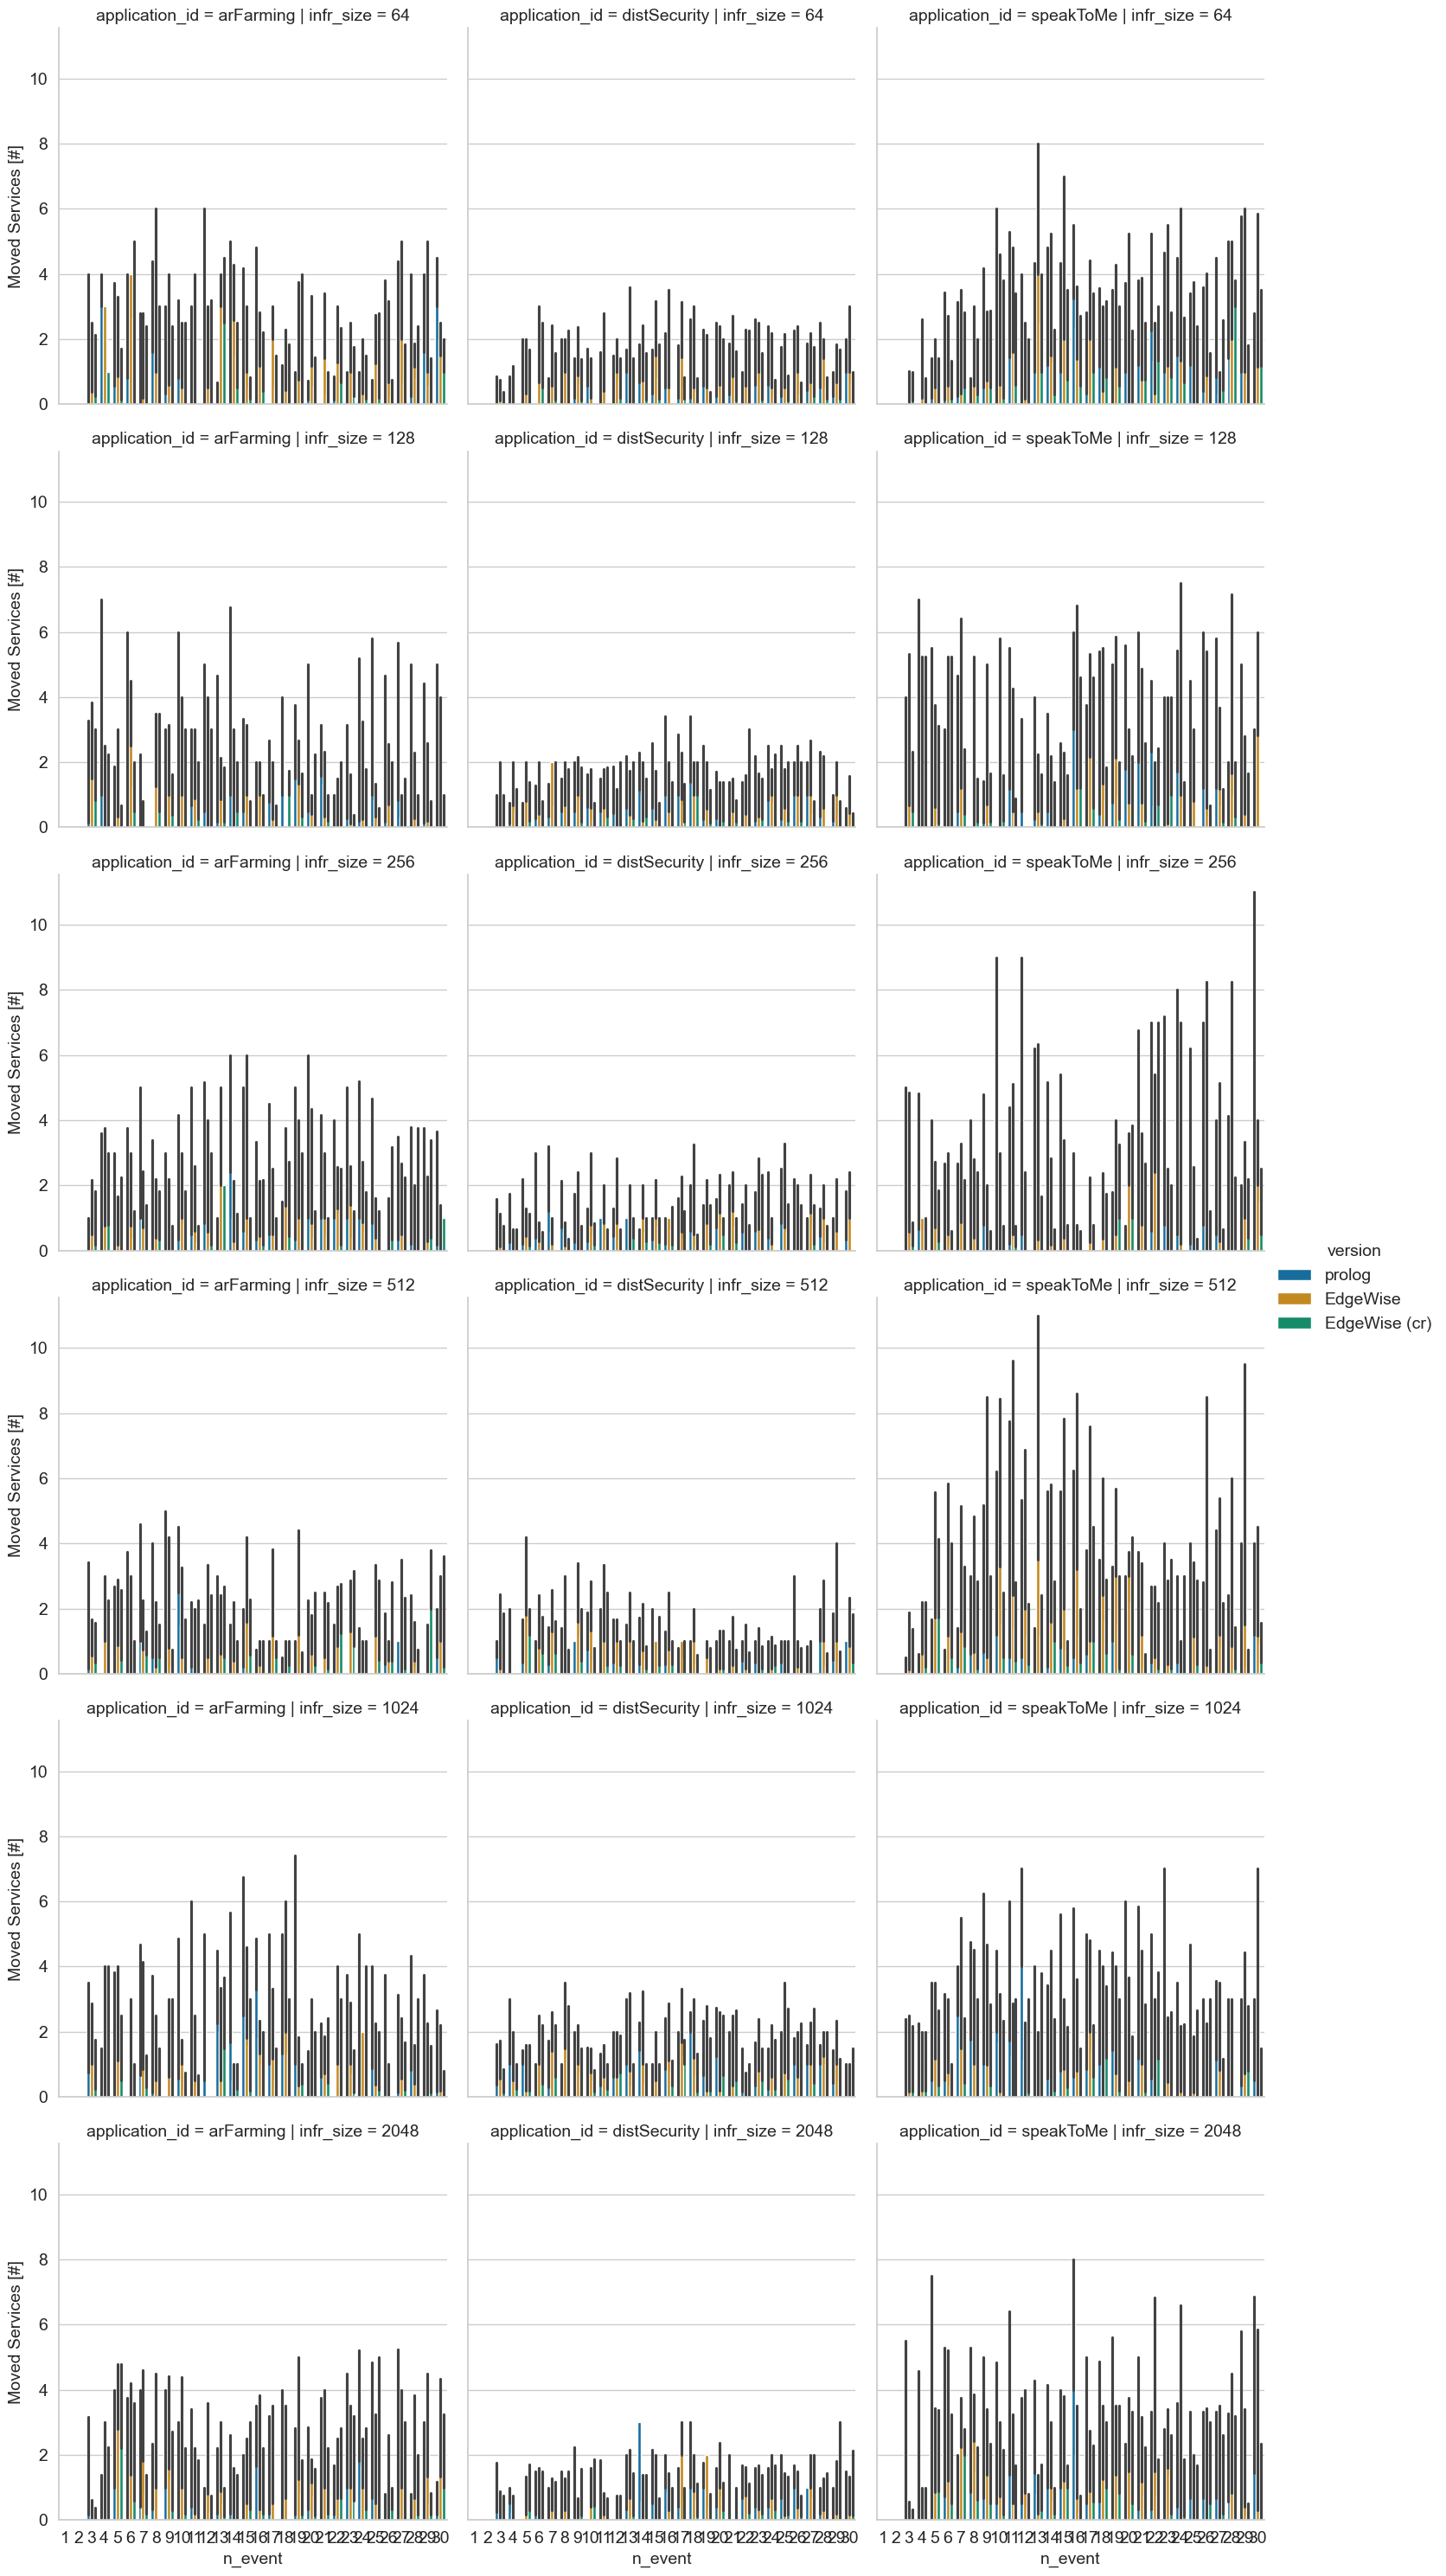

In [ ]:

f = sns.catplot(
    data=df_moved,
    x="n_event",
    y="value",
    hue="version",
    #style="version",
    kind="bar",
    row="nodes",
    col="application_id",
    palette="colorblind",
    hue_order=HUE_ORDER,
    col_order=COL_ORDER,
)

f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Moved Services [#]")

/var/folders/1r/_v8l8s4s5szdklfbt8tg7dwm0000gn/T/ipykernel_65263/2572090816.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[18.181818181818183 66.66666666666666 60.0 33.333333333333336
 28.571428571428566 60.0 58.333333333333336 16.666666666666664 100.0
 3.9999999999999987 0.0 54.347826086956516 78.57142857142857 40.0
 78.57142857142857 35.18518518518518 33.33333333333333 75.51020408163266
 86.1111111111111 30.0 42.857142857142854 28.571428571428577
 30.000000000000004 85.0 80.95238095238095 49.090909090909086 80.0 25.0
 31.25 0.0 77.77777777777779 64.28571428571429 100.0 11.11111111111111
 56.25 50.0 46.666666666666664 57.14285714285715 46.96969696969697
 16.666666666666664 80.0 62.5 66.66666666666667 50.0 -24.999999999999993
 55.00000000000001 -33.33333333333333 85.71428571428571 60.0
 75.99999999999999 57.57575757575758 -50.000000000000014 56.25
 66.66666666666666 60.0 37.49999999999999 20.0 10.

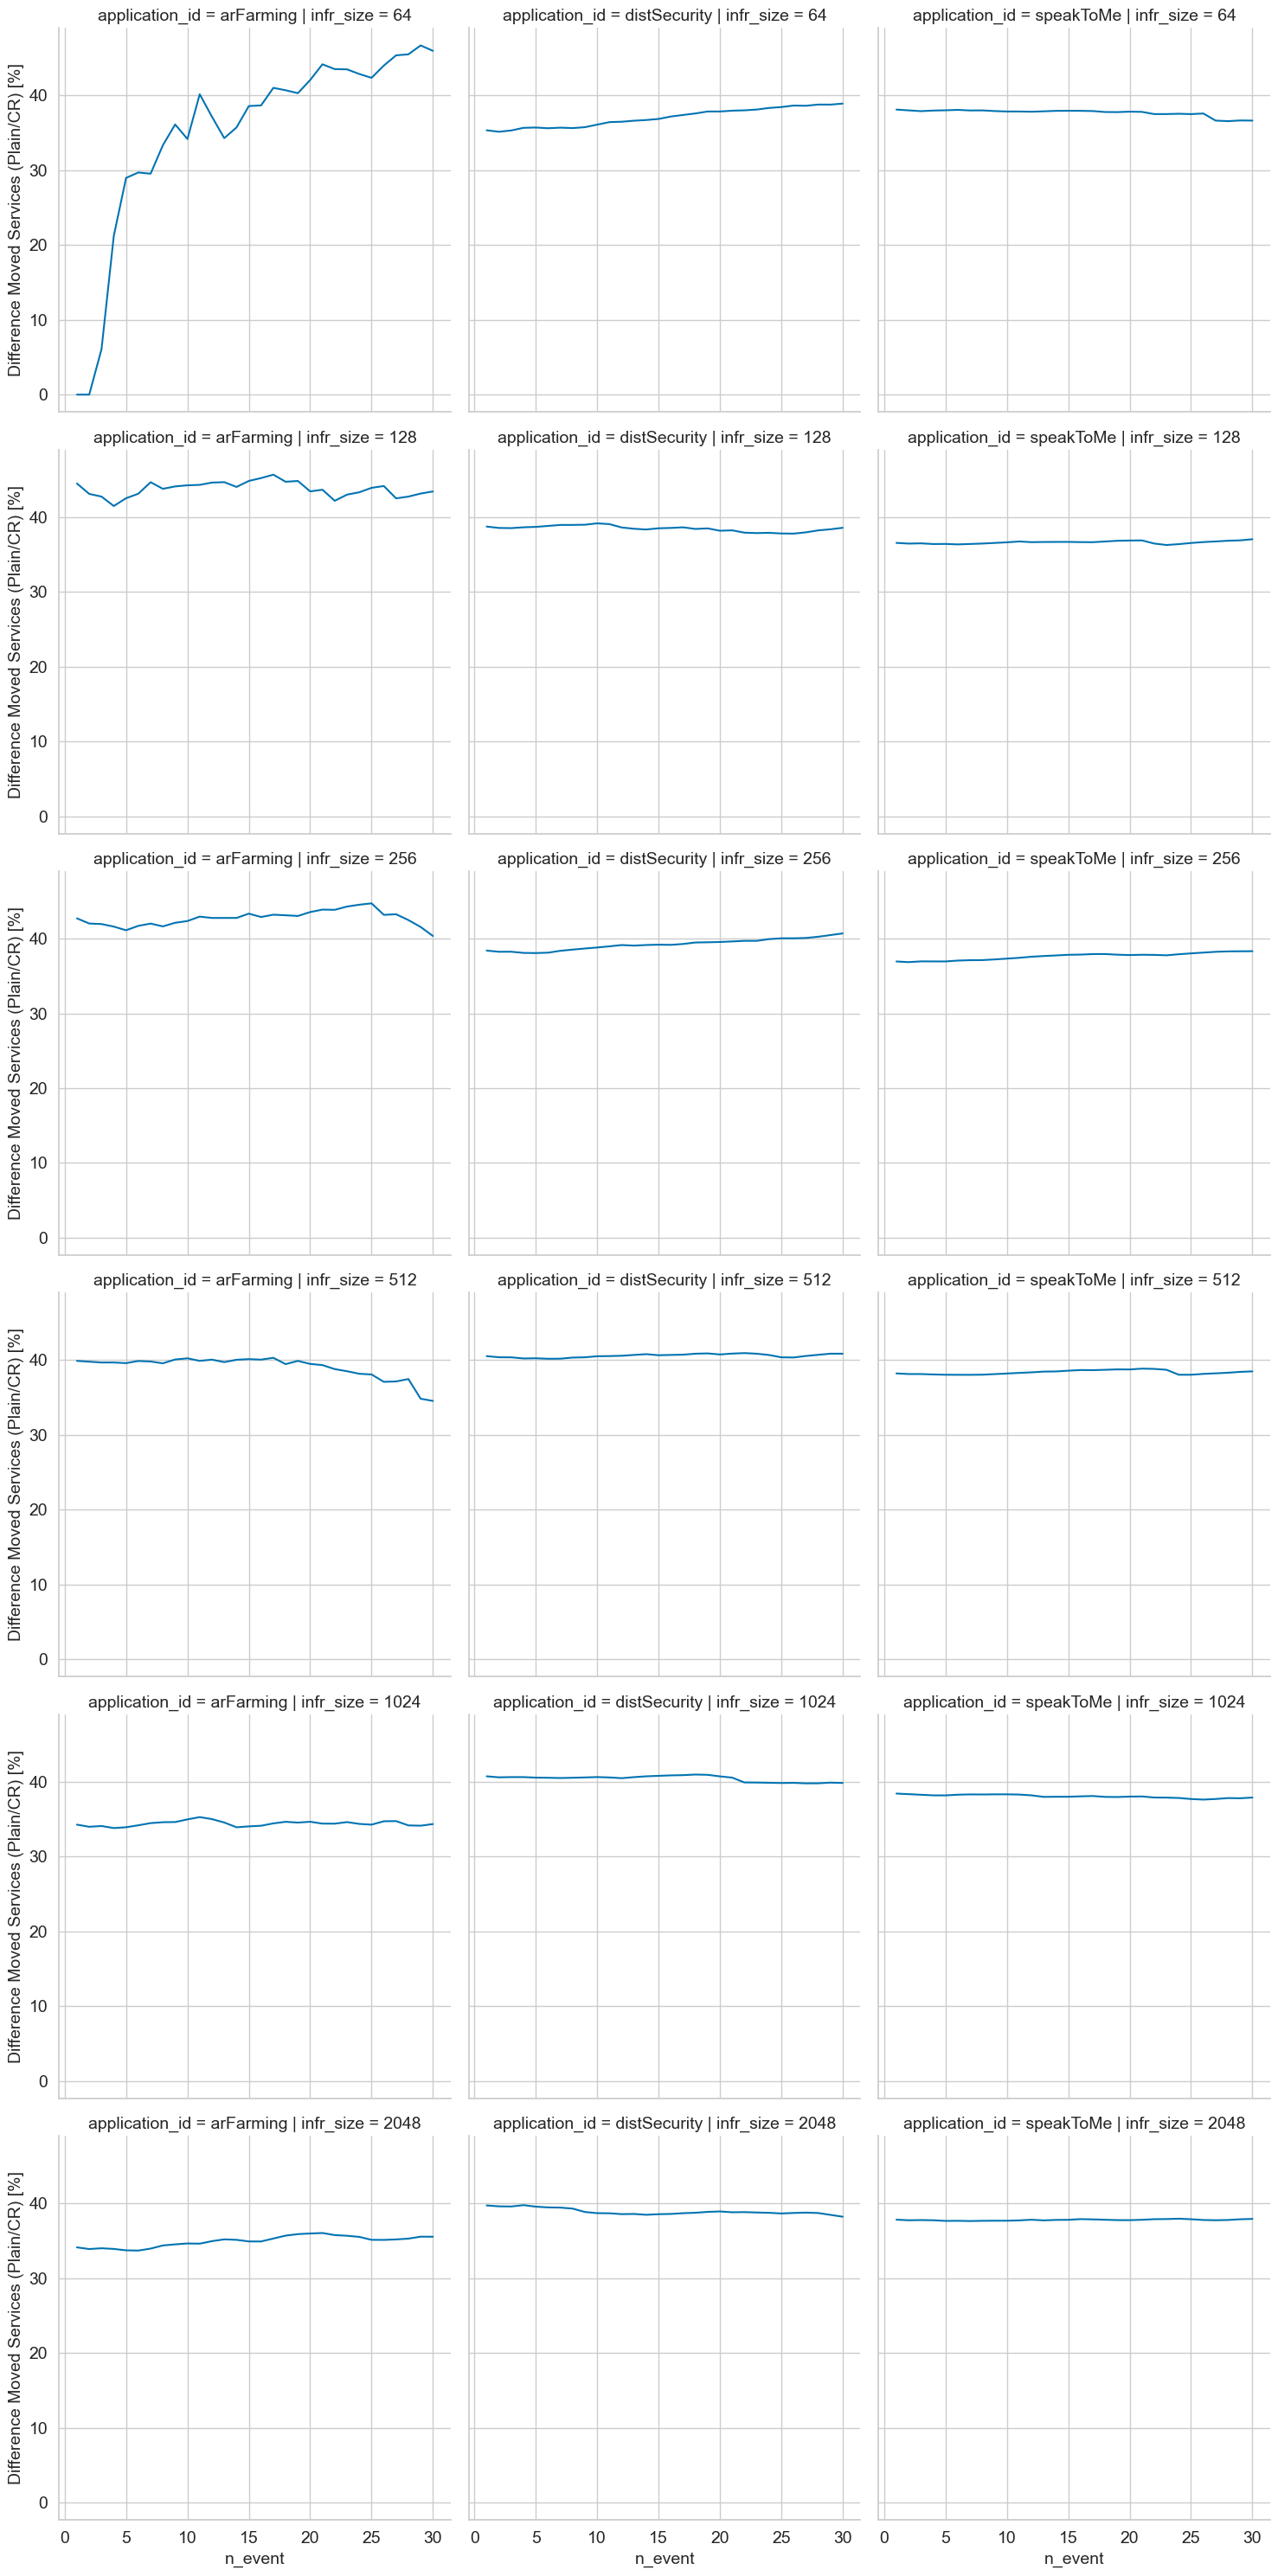

In [ ]:
df_milp_ms = df_moved[df_moved["version"] == "EdgeWise"]
df_milp_cr_ms = df_moved[df_moved["version"] == "EdgeWise (cr)"]

df_milp_ms = (
    df_milp_ms.groupby(["application_id", "nodes", "n_event", "version"])["value"]
    .mean()
    .reset_index()
)
df_milp_cr_ms = (
    df_milp_cr_ms.groupby(["application_id", "nodes", "n_event", "version"])["value"]
    .mean()
    .reset_index()
)
df_milp_cr_ms["diff"] = 0.0
mask = df_milp_ms["value"] != 0.0

df_milp_cr_ms.loc[mask, "diff"] = (
    (df_milp_ms.loc[mask, "value"] - df_milp_cr_ms.loc[mask, "value"]) / df_milp_ms.loc[mask, "value"]
) * 100

df_milp_cr_ms["diff"] = df_milp_cr_ms["diff"].expanding().mean()

f = sns.relplot(
    data=df_milp_cr_ms,
    x="n_event",
    y="diff",
    kind="line",
    markers=True,
    row="nodes",
    col="application_id",
    palette="colorblind",
    col_order=COL_ORDER,
    hue_order=HUE_ORDER,
    # errorbar=None,
)
f.set_titles("application_id = {col_name} | infr_size = {row_name}")
f.set_ylabels("Difference Moved Services (Plain/CR) [%]")

In [134]:
df_diff = df_milp_cr_ms.groupby(["application_id", "nodes"])["diff"]
#df_diff = df_diff.mean().reset_index()

df_diff.describe()

count       mean        std        min        25%  \
application_id nodes                                                      
arFarming      64      30.0  35.054375  12.705080   0.000000  33.551948   
               128     30.0  43.743809   0.980718  41.473695  43.095881   
               256     30.0  42.719392   1.010573  40.349122  42.007840   
               512     29.0  39.027537   1.512027  34.552474  38.524536   
               1024    30.0  34.407102   0.347076  33.808220  34.136253   
               2048    30.0  34.935102   0.717064  33.685603  34.407168   
distSecurity   64      30.0  37.049843   1.251215  35.142430  35.719718   
               128     30.0  38.450728   0.384553  37.778668  38.212993   
               256     30.0  39.217490   0.752969  38.067827  38.565813   
               512     30.0  40.595623   0.235737  40.188353  40.384230   
               1024    30.0  40.422692   0.398685  39.784973  39.902726   
               2048    30.0  38.907364   0.424706  38.214113  38.652808   
speakToMe      64      30.0  37.681038   0.454318  36.558371  37.557756   
               128     30.0  36.608563   0.188577  36.258596  36.451836   
               256     30.0  37.625103   0.465736  36.853879  37.148673   
               512     30.0  38.373406   0.278487  38.042154  38.139798   
               1024    30.0  38.053760   0.220596  37.618106  37.890752   
               2048    30.0  37.781254   0.085346  37.632332  37.727944   

                            50%        75%        max  
application_id nodes                                   
arFarming      64     39.413209  43.333346  46.684677  
               128    43.835482  44.572299  45.662612  
               256    42.761833  43.239319  44.712796  
               512    39.689358  39.909051  40.315458  
               1024   34.401904  34.613775  35.275269  
               2048   35.116628  35.530764  36.033481  
distSecurity   64     37.016636  38.087078  38.906806  
               128    38.503685  38.665945  39.152056  
               256    39.175503  39.698916  40.690541  
               512    40.626595  40.794600  40.947532  
               1024   40.565763  40.696972  40.965839  
               2048   38.751171  39.203835  39.763038  
speakToMe      64     37.852481  37.949915  38.107963  
               128    36.636900  36.730069  37.029792  
               256    37.783898  37.924953  38.316421  
               512    38.309998  38.648180  38.870271  
               1024   38.026319  38.268893  38.421731  
               2048   37.774629  37.845657  37.948157

In [132]:
df_mov = df_moved[~df_moved["version"].isin(["prolog"])]
grouped = df_mov.groupby(["application_id", "nodes", "version"]).agg(
    total_size=("value", "size"),
    zero_count=("value", lambda x: (x == 0).sum()),
    nonzero_count=("value", lambda x: (x != 0).sum()),
).reset_index()

grouped["zero_pct"] = (grouped["zero_count"] / grouped["total_size"]) * 100
grouped["nonzero_pct"] = (grouped["nonzero_count"] / grouped["total_size"]) * 100


grouped.groupby("version")[["nonzero_pct", "zero_pct"]].mean()

,nonzero_pct,zero_pct
version,,
EdgeWise,67.181542,32.818458
EdgeWise (cr),44.810921,55.189079


In [133]:
# Pivot per avere le versioni come colonne
pivoted = df_exec_time.pivot_table(
    index=["n_event", "application_id", "nodes"],
    columns="version",
    values="value"
).reset_index()

pivoted[pivoted["EdgeWise (cr)"] > pivoted["EdgeWise"]]

version,n_event,application_id,nodes,EdgeWise,EdgeWise (cr),prolog
0,1,arFarming,64,0.131222,0.132556,0.014771
1,1,arFarming,128,0.325,0.330222,0.036423
2,1,arFarming,256,1.306,1.328333,0.07143
3,1,arFarming,512,6.025,6.064,0.229191
4,1,arFarming,1024,28.770222,28.858222,1.057073
5,1,arFarming,2048,143.076111,143.821889,4.431806
7,1,distSecurity,128,0.162667,0.163,0.24857
9,1,distSecurity,512,3.121444,3.132,4.559083
13,1,speakToMe,128,0.376222,0.376556,0.043857
16,1,speakToMe,1024,31.221667,31.403333,2.110963
